In [1]:
import os

folders = [
    "governance-logic-ai-banking",
    "governance-logic-ai-banking/data",
    "governance-logic-ai-banking/data/raw",
    "governance-logic-ai-banking/data/processed",
    "governance-logic-ai-banking/notebooks",
    "governance-logic-ai-banking/results",
    "governance-logic-ai-banking/results/figures",
    "governance-logic-ai-banking/src"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Professional project structure created")

✅ Professional project structure created


In [4]:
import shutil

shutil.move(
    "WESTERN_FINAL_DATASET.csv",
    "governance-logic-ai-banking/data/raw/WESTERN_FINAL_DATASET.csv"
)

shutil.move(
    "ISLAMIC_FINAL_DATASET.csv",
    "governance-logic-ai-banking/data/raw/ISLAMIC_FINAL_DATASET.csv"
)

print("✅ Datasets organized successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'WESTERN_FINAL_DATASET.csv'

In [8]:
!pip install transformers torch wordcloud nltk seaborn statsmodels

In [9]:
# =========================================
# IMPORTS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)

from scipy.stats import ttest_ind

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    pipeline
)

import torch

nltk.download("stopwords")

from nltk.corpus import stopwords

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# =========================================
# LOAD DATASETS
# =========================================

western = pd.read_csv(
    "governance-logic-ai-banking/data/raw/WESTERN_FINAL_DATASET.csv"
)

islamic = pd.read_csv(
    "governance-logic-ai-banking/data/raw/ISLAMIC_FINAL_DATASET.csv"
)

# Add labels
western["label"] = "Western"
islamic["label"] = "Islamic"

# Merge datasets
df = pd.concat(
    [western, islamic],
    ignore_index=True
)

print("✅ Dataset loaded successfully")
print(df.shape)

df.head()

✅ Dataset loaded successfully
(564, 8)


,institution,system,region,year,type,source_url,text,label
0,Federal Reserve,Western,USA,2026.0,FOMC Statement,https://www.federalreserve.gov/monetarypolicy/...,"For release at 2:00 p.m. EST January 28, 2026 ...",Western
1,Federal Reserve,Western,USA,2026.0,FOMC Statement,https://www.federalreserve.gov/monetarypolicy/...,FOMC Minutes of the Federal Open Market Commit...,Western
2,Federal Reserve,Western,USA,2026.0,FOMC Statement,https://www.federalreserve.gov/monetarypolicy/...,"For release at 2:00 p.m. EDT March 18, 2026 Av...",Western
3,Federal Reserve,Western,USA,2026.0,FOMC Statement,https://www.federalreserve.gov/monetarypolicy/...,"For release at 2:00 p.m., EDT, March 18, 2026 ...",Western
4,Federal Reserve,Western,USA,2026.0,FOMC Statement,https://www.federalreserve.gov/monetarypolicy/...,FOMC Minutes of the Federal Open Market Commit...,Western


In [11]:
# =========================================
# TEXT CLEANING
# =========================================

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"\s+", " ", text)

    text = re.sub(r"[^a-z\s]", "", text)

    words = [
        w for w in text.split()
        if w not in stop_words and len(w) > 2
    ]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

print("✅ Text cleaning completed")

df[["text", "clean_text"]].head()

✅ Text cleaning completed


,text,clean_text
0,"For release at 2:00 p.m. EST January 28, 2026 ...",release est january available indicators sugge...
1,FOMC Minutes of the Federal Open Market Commit...,fomc minutes federal open market committee jan...
2,"For release at 2:00 p.m. EDT March 18, 2026 Av...",release edt march available indicators suggest...
3,"For release at 2:00 p.m., EDT, March 18, 2026 ...",release edt march summary economic projections...
4,FOMC Minutes of the Federal Open Market Commit...,fomc minutes federal open market committee mar...


In [12]:
df.to_csv(
    "governance-logic-ai-banking/data/processed/cleaned_dataset.csv",
    index=False
)

print("✅ Cleaned dataset saved")

✅ Cleaned dataset saved


In [13]:
print("Dataset Shape:", df.shape)

print("\nBy Label:")
print(df["label"].value_counts())

print("\nColumns:")
print(df.columns)

Dataset Shape: (564, 9)

By Label:
label
Western    291
Islamic    273
Name: count, dtype: int64

Columns:
Index(['institution', 'system', 'region', 'year', 'type', 'source_url', 'text',
       'label', 'clean_text'],
      dtype='object')


In [14]:
df["word_count"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

print(df["word_count"].describe())

count    564.000000
mean     611.312057
std      305.847003
min        0.000000
25%      342.500000
50%      750.500000
75%      874.250000
max      999.000000
Name: word_count, dtype: float64


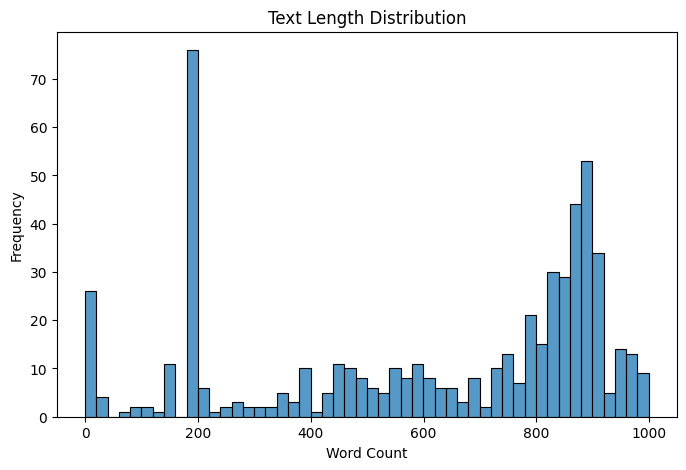

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["word_count"], bins=50)

plt.title("Text Length Distribution")

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.savefig(
    "governance-logic-ai-banking/results/figures/text_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
readme = """
# Governance Logic Analysis in Islamic and Western Banking

## Overview
This project analyzes governance differences between Islamic and Western banking systems using NLP, Machine Learning, and Large Language Models.

## Features
- Text preprocessing
- TF-IDF analysis
- Governance index
- Machine learning validation
- LLM evaluation

## Technologies
- Python
- NLP
- Transformers
- Machine Learning

## Author
Zia Ul Rehman Zafar
"""

with open(
    "governance-logic-ai-banking/README.md",
    "w"
) as f:
    f.write(readme)

print("✅ README created")

✅ README created


In [17]:
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
nltk
wordcloud
torch
transformers
scipy
statsmodels
jupyter
"""

with open(
    "governance-logic-ai-banking/requirements.txt",
    "w"
) as f:
    f.write(requirements)

print("✅ requirements.txt created")

✅ requirements.txt created


In [18]:
# =========================================
# TF-IDF VECTORIZATION
# =========================================

tfidf = TfidfVectorizer(
    max_features=2000
)

X_tfidf = tfidf.fit_transform(
    df["clean_text"]
)

print("✅ TF-IDF completed")

print("Shape:", X_tfidf.shape)

✅ TF-IDF completed
Shape: (564, 2000)


In [19]:
# =========================================
# TOP WORD ANALYSIS
# =========================================

vectorizer = CountVectorizer(
    max_features=50
)

X_words = vectorizer.fit_transform(
    df["clean_text"]
)

word_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "frequency": X_words.toarray().sum(axis=0)
})

word_freq = word_freq.sort_values(
    by="frequency",
    ascending=False
)

print(word_freq.head(20))

           word  frequency
18    financial       3688
27      islamic       3179
24    inflation       2794
32     monetary       2729
38       policy       2610
5         board       2574
13     economic       2505
4          bank       2463
29       market       2211
16      federal       1886
41         rate       1833
21       growth       1617
6     committee       1608
19       global       1511
17      finance       1268
14         euro       1251
9   development       1248
34         open       1245
0        aaoifi       1180
3          area       1164


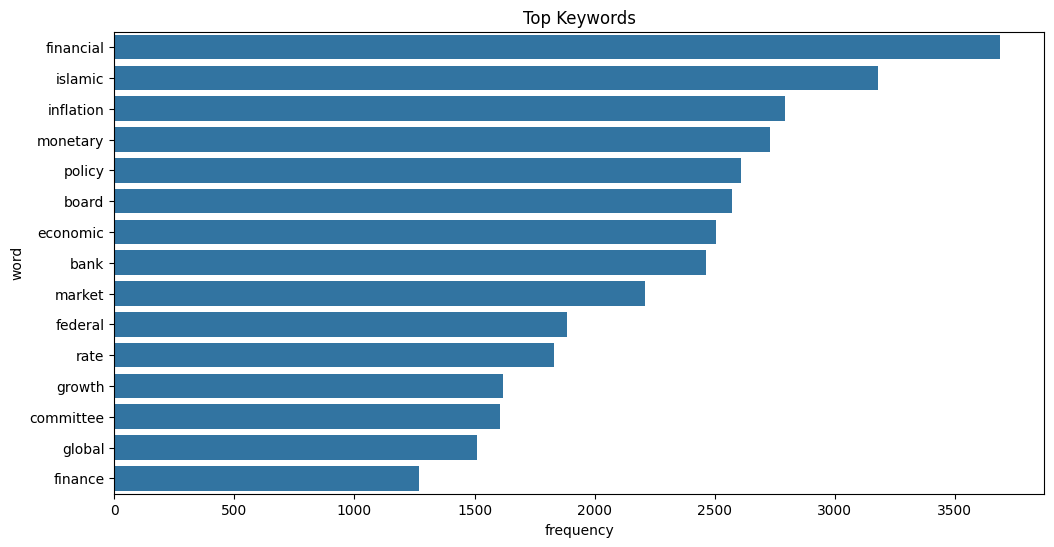

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="frequency",
    y="word",
    data=word_freq.head(15)
)

plt.title("Top Keywords")

plt.savefig(
    "governance-logic-ai-banking/results/figures/top_keywords.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

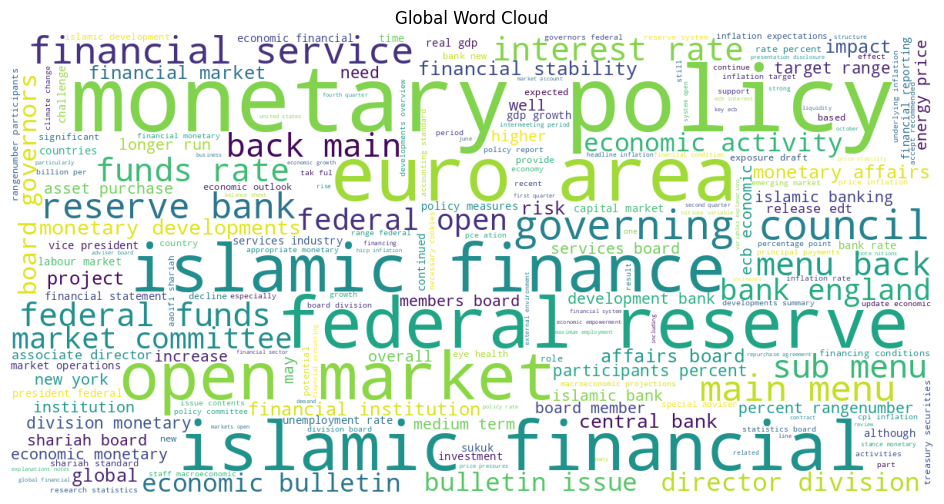

In [21]:
# =========================================
# WORD CLOUD
# =========================================

text_blob = " ".join(
    df["clean_text"].values
)

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text_blob)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Global Word Cloud")

plt.savefig(
    "governance-logic-ai-banking/results/figures/wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# =========================================
# KMEANS CLUSTERING
# =========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(X_tfidf)

print("✅ Clustering completed")

print(df["cluster"].value_counts())

✅ Clustering completed
cluster
1    273
2    219
0     72
Name: count, dtype: int64


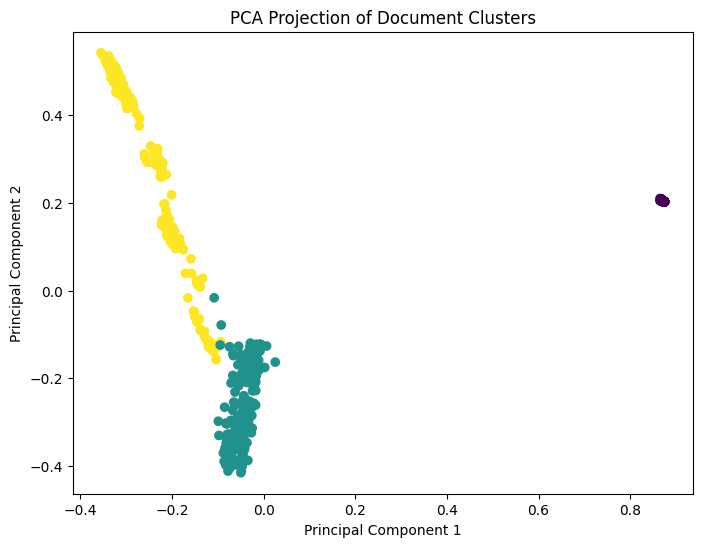

In [23]:
# =========================================
# PCA DIMENSIONALITY REDUCTION
# =========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_tfidf.toarray()
)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster"]
)

plt.title("PCA Projection of Document Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.savefig(
    "governance-logic-ai-banking/results/figures/pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# =========================================
# GOVERNANCE LOGIC KEYWORDS
# =========================================

tech_keywords = [
    "interest",
    "inflation",
    "monetary",
    "policy",
    "liquidity",
    "market",
    "central bank"
]

ethical_keywords = [
    "shariah",
    "ethical",
    "halal",
    "haram",
    "compliance",
    "fatwa",
    "moral"
]

risk_keywords = [
    "risk",
    "uncertainty",
    "stability",
    "volatility",
    "crisis",
    "shock"
]

print("✅ Governance keywords initialized")

✅ Governance keywords initialized


In [25]:
# =========================================
# GOVERNANCE SCORING
# =========================================

def count_keywords(text, keywords):

    return sum(
        text.count(word)
        for word in keywords
    )

df["tech_score"] = df["clean_text"].apply(
    lambda x: count_keywords(x, tech_keywords)
)

df["ethical_score"] = df["clean_text"].apply(
    lambda x: count_keywords(x, ethical_keywords)
)

df["risk_score"] = df["clean_text"].apply(
    lambda x: count_keywords(x, risk_keywords)
)

print("✅ Governance scores computed")

✅ Governance scores computed


In [26]:
# =========================================
# NORMALIZED GOVERNANCE INDEX
# =========================================

def compute_ratios(row):

    total = (
        row["tech_score"]
        + row["ethical_score"]
        + row["risk_score"]
        + 1e-9
    )

    return pd.Series({
        "tech_ratio":
            row["tech_score"] / total,

        "ethical_ratio":
            row["ethical_score"] / total,

        "risk_ratio":
            row["risk_score"] / total
    })

ratios = df.apply(
    compute_ratios,
    axis=1
)

df = pd.concat(
    [df, ratios],
    axis=1
)

print("✅ Governance ratios computed")

✅ Governance ratios computed


In [27]:
# =========================================
# SYSTEM COMPARISON
# =========================================

system_summary = df.groupby(
    "label"
)[[
    "tech_ratio",
    "ethical_ratio",
    "risk_ratio"
]].mean()

print(system_summary)

         tech_ratio  ethical_ratio  risk_ratio
label                                         
Islamic    0.332058       0.280503    0.196963
Western    0.849158       0.000164    0.150678


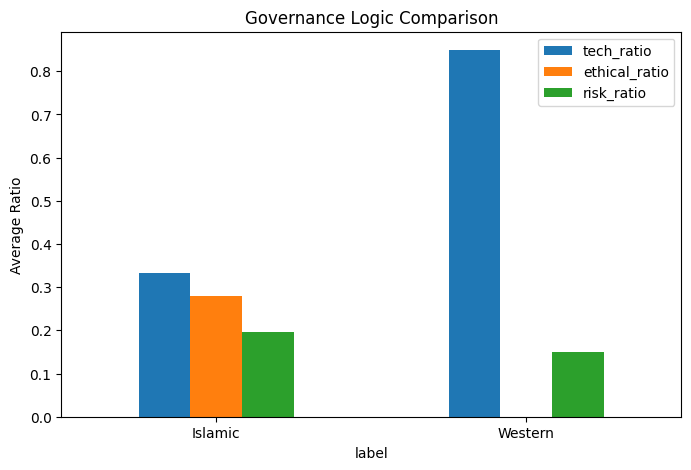

In [28]:
system_summary.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Governance Logic Comparison"
)

plt.ylabel("Average Ratio")

plt.xticks(rotation=0)

plt.savefig(
    "governance-logic-ai-banking/results/figures/governance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
df.to_csv(
    "governance-logic-ai-banking/data/processed/FINAL_ENRICHED_DATASET.csv",
    index=False
)

print("✅ FINAL_ENRICHED_DATASET saved")

✅ FINAL_ENRICHED_DATASET saved


In [30]:
# =========================================
# STATISTICAL VALIDATION IMPORTS
# =========================================

from scipy.stats import ttest_ind
from math import sqrt

print("✅ Statistical libraries loaded")

✅ Statistical libraries loaded


In [31]:
# =========================================
# COHEN'S D EFFECT SIZE
# =========================================

def cohens_d(x, y):

    nx = len(x)
    ny = len(y)

    pooled_std = sqrt(
        (
            ((nx - 1) * np.var(x))
            +
            ((ny - 1) * np.var(y))
        )
        /
        (nx + ny - 2)
    )

    return (
        np.mean(x) - np.mean(y)
    ) / pooled_std

print("✅ Effect size function created")

✅ Effect size function created


In [32]:
# =========================================
# T-TEST VALIDATION
# =========================================

metrics = [
    "tech_ratio",
    "ethical_ratio",
    "risk_ratio"
]

for metric in metrics:

    western_values = df[
        df["label"] == "Western"
    ][metric]

    islamic_values = df[
        df["label"] == "Islamic"
    ][metric]

    t_stat, p_value = ttest_ind(
        western_values,
        islamic_values,
        equal_var=False
    )

    d = cohens_d(
        western_values,
        islamic_values
    )

    print("\n========================")
    print("Metric:", metric)

    print("T-statistic:", round(t_stat, 4))

    print("P-value:", round(p_value, 6))

    print("Cohen's d:", round(d, 4))


Metric: tech_ratio
T-statistic: 25.5486
P-value: 0.0
Cohen's d: 2.2193

Metric: ethical_ratio
T-statistic: -12.6673
P-value: 0.0
Cohen's d: -1.104

Metric: risk_ratio
T-statistic: -2.91
P-value: 0.003868
Cohen's d: -0.2523


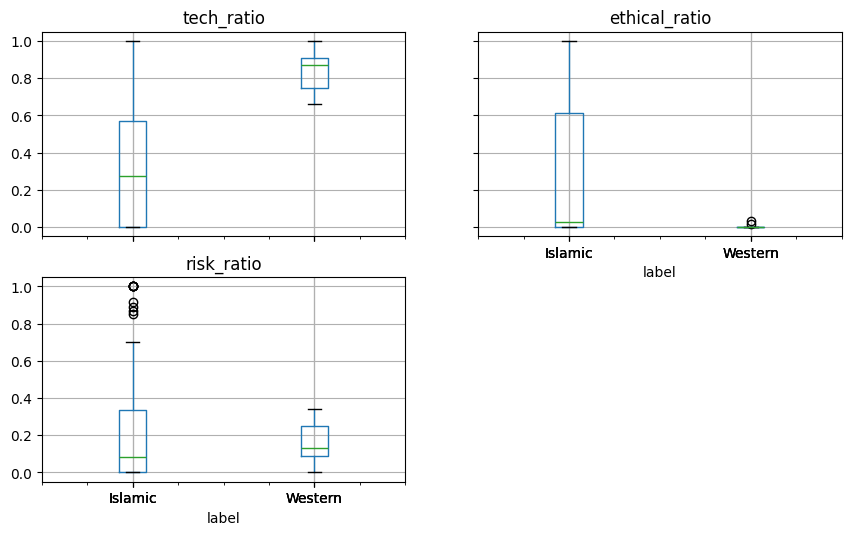

In [33]:
# =========================================
# GOVERNANCE DISTRIBUTION
# =========================================

df.boxplot(
    column=[
        "tech_ratio",
        "ethical_ratio",
        "risk_ratio"
    ],
    by="label",
    figsize=(10,6)
)

plt.suptitle("")

plt.title(
    "Governance Ratio Distribution"
)

plt.savefig(
    "governance-logic-ai-banking/results/figures/governance_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
# =========================================
# GOVERNANCE CLASSIFICATION
# =========================================

def classify_governance(row):

    if row["tech_ratio"] > 0.6:
        return "Technocratic"

    elif row["ethical_ratio"] > 0.3:
        return "Ethical"

    else:
        return "Hybrid"

df["target"] = df.apply(
    classify_governance,
    axis=1
)

print("✅ Governance labels created")

print(df["target"].value_counts())

✅ Governance labels created
target
Technocratic    351
Hybrid          115
Ethical          98
Name: count, dtype: int64


In [35]:
# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["target"],
    test_size=0.2,
    random_state=42
)

print("✅ Train-test split completed")

print("Training Size:", len(X_train))

print("Testing Size:", len(X_test))

✅ Train-test split completed
Training Size: 451
Testing Size: 113


In [36]:
# =========================================
# TF-IDF FOR MACHINE LEARNING
# =========================================

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(
    X_train
)

X_test_vec = vectorizer.transform(
    X_test
)

print("✅ TF-IDF vectorization completed")

✅ TF-IDF vectorization completed


In [37]:
# =========================================
# LOGISTIC REGRESSION MODEL
# =========================================

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_vec,
    y_train
)

print("✅ Logistic Regression trained")

✅ Logistic Regression trained


In [38]:
# =========================================
# MODEL PREDICTIONS
# =========================================

y_pred = model.predict(
    X_test_vec
)

print("✅ Predictions completed")

✅ Predictions completed


In [39]:
# =========================================
# MODEL EVALUATION
# =========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.8761

Classification Report:

              precision    recall  f1-score   support

     Ethical       0.95      0.90      0.92        20
      Hybrid       0.52      0.87      0.65        15
Technocratic       0.99      0.87      0.93        78

    accuracy                           0.88       113
   macro avg       0.82      0.88      0.83       113
weighted avg       0.92      0.88      0.89       113



In [40]:
# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[18  2  0]
 [ 1 13  1]
 [ 0 10 68]]


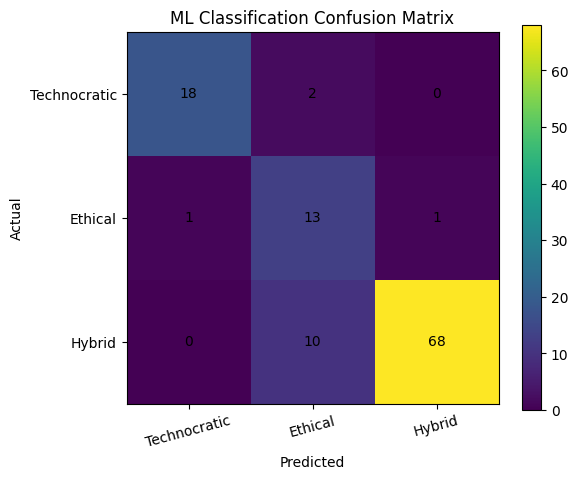

In [41]:
# =========================================
# CONFUSION MATRIX PLOT
# =========================================

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title(
    "ML Classification Confusion Matrix"
)

plt.colorbar()

labels = [
    "Technocratic",
    "Ethical",
    "Hybrid"
]

plt.xticks(
    range(len(labels)),
    labels,
    rotation=15
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(len(labels)):
    for j in range(len(labels)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.savefig(
    "governance-logic-ai-banking/results/figures/ml_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
df.to_csv(
    "governance-logic-ai-banking/data/processed/FINAL_WITH_SCORES.csv",
    index=False
)

print("✅ FINAL_WITH_SCORES saved")

✅ FINAL_WITH_SCORES saved


In [58]:
!pip install sentencepiece accelerate

In [59]:
# =========================================
# LLM VALIDATION IMPORTS
# =========================================

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    pipeline
)

from sklearn.metrics import (
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    accuracy_score
)

from statsmodels.stats.contingency_tables import mcnemar

import torch
import numpy as np

print("✅ LLM libraries loaded")

✅ LLM libraries loaded


In [60]:
# =========================================
# CREATE VALIDATION SAMPLE
# =========================================

sample_df = df.sample(
    60,
    random_state=42
).copy()

print("✅ Validation sample created")

print(sample_df.shape)

✅ Validation sample created
(60, 18)


In [61]:
# =========================================
# INDEX LABELS
# =========================================

def classify_index(row):

    if row["tech_ratio"] > 0.6:
        return "Technocratic"

    elif row["ethical_ratio"] > 0.3:
        return "Ethical"

    else:
        return "Hybrid"

sample_df["index_label"] = sample_df.apply(
    classify_index,
    axis=1
)

print(
    sample_df["index_label"].value_counts()
)

index_label
Technocratic    43
Ethical         11
Hybrid           6
Name: count, dtype: int64


In [62]:
# =========================================
# LOAD FLAN-T5
# =========================================

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

llm_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
).to(device)

print("✅ FLAN-T5 loaded")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ FLAN-T5 loaded


In [63]:
# =========================================
# LABEL CLEANER
# =========================================

def clean_label(text):

    text = text.lower()

    if "technocratic" in text:
        return "Technocratic"

    elif "ethical" in text:
        return "Ethical"

    elif "hybrid" in text:
        return "Hybrid"

    else:
        return "Hybrid"

print("✅ Label cleaner ready")

✅ Label cleaner ready


In [64]:
# =========================================
# PROMPT ENGINEERING
# =========================================

def build_prompt(text, style):

    if style == "simple":

        return f"""
Classify this text into:
Technocratic, Ethical, or Hybrid.

Text:
{text[:600]}

Answer with one word.
"""

    elif style == "instruction":

        return f"""
You are an expert in finance and AI ethics.

Classify the following text into ONLY ONE category:

Technocratic
Ethical
Hybrid

Text:
{text[:600]}

Answer:
"""

    elif style == "strict":

        return f"""
Return ONLY one label from this list:

[Technocratic, Ethical, Hybrid]

Text:
{text[:600]}

Label:
"""

print("✅ Prompt templates created")

✅ Prompt templates created


In [65]:
# =========================================
# LLM INFERENCE FUNCTION
# =========================================

def run_llm(texts, style):

    prompts = [
        build_prompt(t, style)
        for t in texts
    ]

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=10
    )

    decoded = [
        tokenizer.decode(
            o,
            skip_special_tokens=True
        )
        for o in outputs
    ]

    return [
        clean_label(d)
        for d in decoded
    ]

print("✅ LLM inference function ready")

✅ LLM inference function ready


In [66]:
# =========================================
# RUN FLAN-T5
# =========================================

texts = sample_df["text"].tolist()

y_true = sample_df["index_label"]

results = {}

for style in [
    "simple",
    "instruction",
    "strict"
]:

    predictions = run_llm(
        texts,
        style
    )

    results[f"flan_{style}"] = predictions

print("✅ FLAN-T5 validation completed")

✅ FLAN-T5 validation completed


In [67]:
# =========================================
# ZERO-SHOT BASELINE
# =========================================

bart_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

candidate_labels = [
    "Technocratic",
    "Ethical",
    "Hybrid"
]

print("✅ BART baseline loaded")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

✅ BART baseline loaded


In [74]:
# =========================================
# RUN BART VALIDATION
# =========================================

def run_bart(texts):

    predictions = []

    for text in texts:

        result = bart_classifier(
            text[:600],
            candidate_labels
        )

        predictions.append(
            result["labels"][0]
        )

    return predictions

bart_predictions = run_bart(texts)

results["bart"] = bart_predictions

print("✅ BART validation completed")

✅ BART validation completed


In [75]:
# =========================================
# EVALUATION FUNCTION
# =========================================

def evaluate_model(
    name,
    y_true,
    y_pred
):

    print("\n========================")
    print(name.upper())
    print("========================")

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    print(
        "Accuracy:",
        round(accuracy, 4)
    )

    print(
        "Kappa:",
        round(kappa, 4)
    )

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

In [76]:
# =========================================
# PRINT RESULTS
# =========================================

for model_name, predictions in results.items():

    evaluate_model(
        model_name,
        y_true,
        predictions
    )


FLAN_SIMPLE
Accuracy: 0.15
Kappa: 0.0158

Classification Report:

              precision    recall  f1-score   support

     Ethical       0.50      0.18      0.27        11
      Hybrid       0.09      0.83      0.17         6
Technocratic       0.67      0.05      0.09        43

    accuracy                           0.15        60
   macro avg       0.42      0.35      0.17        60
weighted avg       0.58      0.15      0.13        60


FLAN_INSTRUCTION
Accuracy: 0.7167
Kappa: 0.0

Classification Report:

              precision    recall  f1-score   support

     Ethical       0.00      0.00      0.00        11
      Hybrid       0.00      0.00      0.00         6
Technocratic       0.72      1.00      0.83        43

    accuracy                           0.72        60
   macro avg       0.24      0.33      0.28        60
weighted avg       0.51      0.72      0.60        60


FLAN_STRICT
Accuracy: 0.7
Kappa: 0.0714

Classification Report:

              precision    recall 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [77]:
# =========================================
# MCNEMAR TEST
# =========================================

best_llm = results["flan_strict"]

correct_llm = (
    np.array(best_llm)
    ==
    np.array(y_true)
)

correct_bart = (
    np.array(bart_predictions)
    ==
    np.array(y_true)
)

table = [

    [
        np.sum(
            (correct_llm == True)
            &
            (correct_bart == True)
        ),

        np.sum(
            (correct_llm == True)
            &
            (correct_bart == False)
        )
    ],

    [
        np.sum(
            (correct_llm == False)
            &
            (correct_bart == True)
        ),

        np.sum(
            (correct_llm == False)
            &
            (correct_bart == False)
        )
    ]
]

mcnemar_result = mcnemar(
    table,
    exact=True
)

print("McNemar Statistic:",
      mcnemar_result.statistic)

print("P-value:",
      mcnemar_result.pvalue)

if mcnemar_result.pvalue < 0.05:

    print("✅ Significant difference")

else:

    print("⚠️ No significant difference")

McNemar Statistic: 6.0
P-value: 1.0087482138487759e-07
✅ Significant difference


In [78]:
sample_df.to_csv(
    "governance-logic-ai-banking/data/processed/LLM_VALIDATION_RESULTS.csv",
    index=False
)

print("✅ LLM validation results saved")

✅ LLM validation results saved
